# Weighted retained-cycle hold-one-float-out validation

This notebook brings the earlier uncertainty-extension sketch into the same evaluation frame used by `2-jana-holdout-validation.ipynb`. Both notebooks now:
- rebuild the same calibrated retained archive
- hold out complete floats by `PLATFORM_NUMBER`
- predict temperature, salinity, and sound speed on the common `5-500 m` depth grid
- aggregate RMSE, MAE, and bias by depth

The difference is the predictor. Here, nearby retained cycles are combined with simple spatial, seasonal, and broader interannual weights instead of the flat unweighted Jana-style local mean used in the benchmark notebook.

It is the third notebook in the acoustics sequence. Notebook `2` established the strict flat-kernel benchmark; this notebook is the first controlled attempt to improve that benchmark without changing the retained archive itself.

## Comparison target

This notebook should be read as the weighted retained-cycle counterpart to `2-jana-holdout-validation.ipynb`:
- `2-jana-holdout-validation`: flat local retained-cycle mean inside a `2° x 2°` kernel
- `3-uncertainty-extension`: weighted retained-cycle mean inside the same spatial kernel, with added seasonal and interannual weighting

That alignment is deliberate. It makes the two notebooks directly comparable as baseline-versus-extension held-out validation runs.




In [1]:
from dataclasses import dataclass
from datetime import timedelta as td
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import gsw
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seawater as sw
from tqdm.auto import tqdm



/tmp/ipykernel_11425/604051994.py:11: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


In [2]:
from argo_interp.data import data_filter, get_data
from argo_interp.cycle.adapter import LinearAdapter
from argo_interp.cycle.model import Model
from argo_interp.cycle.domain import ModelData, ModelMeta
from argo_interp.cycle.config import ModelSettings, ModelKwargs



/home/jcherry/Documents/storage/git/argo-data-interpolation/.venv/bin/python: No module named pip


## 1. Pull the Bay of Bengal Argo archive directly

This notebook now performs its own Argo pull so it can be run independently of
the earlier notebooks while still reconstructing the same starting archive.




In [3]:
notebook_dir = Path(".")
data_path = notebook_dir / "data"
chart_path = data_path / "charts"
chart_path.mkdir(exist_ok=True, parents=True)

box = [
    80, 99,
    6, 23,
    0, 750,
    "2011-01-01", "2020-12-31",
]
ds = get_data(box, progress=True)



Final post-processing of the merged dataset ...


## 2. Rebuild the same calibrated Jana retained archive

To keep the weighted extension comparable to the flat Jana-style baseline, this notebook rebuilds the same retained archive assumptions:
- QC flags `1` and `2` only
- cycles must sample the upper `20 m` and extend to `500 m` or deeper
- duplicate pressure rows are averaged before fitting
- linear interpolation is used to place retained cycles on the common depth grid
- the calibrated `3 SD` whole-profile outlier screen is applied after gridding




In [4]:
ds_filters = [
    ds["PRES_QC"].isin([1, 2]),
    ds["TEMP_QC"].isin([1, 2]),
    ds["PSAL_QC"].isin([1, 2]),
]
ds = data_filter(ds, ds_filters)

settings = ModelSettings(
    n_folds=2,
    model_kwargs=ModelKwargs(
        temperature=dict(extrapolate=True),
        salinity=dict(extrapolate=True),
    ),
)

models = {}

cycles = len(ds[["PLATFORM_NUMBER", "CYCLE_NUMBER", "DIRECTION"]].to_dataframe().drop_duplicates())
t = tqdm(ds.groupby(["PLATFORM_NUMBER", "CYCLE_NUMBER", "DIRECTION"]), total=cycles)
for (platform_number, cycle_number, direction), cycle_ds in t:
    pressure = cycle_ds["PRES"].values
    temperature = cycle_ds["TEMP"].values
    salinity = cycle_ds["PSAL"].values

    latitude = cycle_ds["LATITUDE"].values[0]
    longitude = cycle_ds["LONGITUDE"].values[0]
    timestamp = cycle_ds["TIME"].values[0]

    if cycle_ds.sizes["N_POINTS"] < 2:
        continue

    if pressure.min() > gsw.p_from_z(-20, latitude):
        continue
    if pressure.max() < gsw.p_from_z(-500, latitude):
        continue

    model_data = ModelData(
        pressure=pressure,
        temperature=temperature,
        salinity=salinity,
    ).clean_duplicates("mean")

    model_meta = ModelMeta(
        platform_number=str(int(platform_number)),
        cycle_number=str(int(cycle_number)),
        direction=direction,
        latitude=latitude,
        longitude=longitude,
        timestamp=timestamp,
        profile_pressure=(pressure.min(), pressure.max()),
    )
    cycle_id = model_meta.cycle_id

    linear_model = Model.build(model_meta, model_data, LinearAdapter, settings)
    models[cycle_id] = linear_model
    t.set_postfix(model_count=len(models))



  0%|          | 0/21005 [00:00<?, ?it/s]

In [5]:
depth_grid = pd.Index(np.arange(5, 501, 1), name="depth")

pres_profiles = []
temp_profiles = []
sal_profiles = []
cycle_records = []

for cycle_id, model in tqdm(models.items()):
    pressure_grid = pd.Series(gsw.p_from_z(-depth_grid, model.meta.latitude), index=depth_grid, name=cycle_id)
    interp = model.interpolate(pressure_grid).to_frame().set_index(pressure_grid.index)

    pres_profiles.append(pressure_grid)
    temp_profiles.append(interp["temperature"].rename(cycle_id))
    sal_profiles.append(interp["salinity"].rename(cycle_id))
    cycle_records.append({
        "cycle_id": cycle_id,
        "platform_number": model.meta.platform_number,
        "cycle_number": model.meta.cycle_number,
        "direction": model.meta.direction,
        "latitude": model.meta.latitude,
        "longitude": model.meta.longitude,
        "timestamp": model.meta.timestamp,
    })

pres_profiles = pd.concat(pres_profiles, axis=1)
temp_profiles = pd.concat(temp_profiles, axis=1)
sal_profiles = pd.concat(sal_profiles, axis=1)
cycle_metadata = pd.DataFrame.from_records(cycle_records).set_index("cycle_id")



  0%|          | 0/15663 [00:00<?, ?it/s]

In [6]:
temp_mean = pd.concat([
    temp_profiles.mean(axis=1).rename("mean"),
    temp_profiles.std(axis=1).rename("stdev"),
], axis=1)
sal_mean = pd.concat([
    sal_profiles.mean(axis=1).rename("mean"),
    sal_profiles.std(axis=1).rename("stdev"),
], axis=1)

temp_stdev = temp_mean["stdev"].replace(0, np.nan)
sal_stdev = sal_mean["stdev"].replace(0, np.nan)

temp_z_profiles = (temp_profiles - temp_mean["mean"].values[:, np.newaxis]) / temp_stdev.values[:, np.newaxis]
sal_z_profiles = (sal_profiles - sal_mean["mean"].values[:, np.newaxis]) / sal_stdev.values[:, np.newaxis]

sd_val = 3
temp_fail = (temp_z_profiles.abs() >= sd_val).any(axis=0)
sal_fail = (sal_z_profiles.abs() >= sd_val).any(axis=0)
active_cycles = temp_fail.index[~temp_fail & ~sal_fail]

pres_active_profiles = pres_profiles[active_cycles]
temp_active_profiles = temp_profiles[active_cycles]
sal_active_profiles = sal_profiles[active_cycles]
active_cycles_metadata = cycle_metadata.loc[active_cycles].copy()
sound_speed_profiles = pd.DataFrame(
    sw.svel(sal_active_profiles, temp_active_profiles, pres_active_profiles),
    index=temp_active_profiles.index,
    columns=temp_active_profiles.columns,
)

print(f"Retained active cycles: {len(active_cycles):,}")
print(f"Retained floats: {active_cycles_metadata['platform_number'].nunique():,}")



Retained active cycles: 13,400
Retained floats: 138


## 3. Define the weighted retained-cycle predictor

The predictor uses the same flat spatial kernel as the Jana benchmark notebook, but it adds three weight components:
- geographic distance inside the `2° x 2°` kernel
- cyclical week-of-year alignment
- broader interannual time separation

The weighted average is computed directly on the retained-cycle profiles already placed on the common depth grid.

The weighting function intentionally uses only the exponential numerator of a Gaussian-style kernel. The normalizing constant is omitted because these terms are used only as relative weights and are rescaled again before prediction; carrying the denominator would add computation without changing the relative ranking of cycles or the normalized weighted mean when each component uses a fixed variance.

The bandwidth choices in `HoldoutConfig` are heuristic starting values, not source-backed constants. The `dist_stdev_cutoff`, `week_stdev_cutoff`, and `annual_stdev_years` settings were chosen with common-sense tapering in mind so weights decay across the local box and across seasonal and interannual separation, but they should be treated as provisional hyperparameters rather than as validated scientific defaults.

A proper sensitivity analysis over these settings is an obvious next step, but it is deferred here because each full holdout run is expensive enough that a naive sweep would be wasteful. The defensible next move is a planned sensitivity design rather than ad hoc retuning.




In [7]:
@dataclass(frozen=True, slots=True)
class HoldoutConfig:
    kernel_half_width_deg: float = 1.0
    min_cycles: int = 30
    seasonal_window_weeks: int = 8
    dist_stdev_cutoff: float = 3.0
    week_stdev_cutoff: float = 3.0
    annual_stdev_years: float = 2.0
    max_platforms: int | None = None
    random_seed: int = 42


config = HoldoutConfig()
config



HoldoutConfig(kernel_half_width_deg=1.0, min_cycles=30, seasonal_window_weeks=8, dist_stdev_cutoff=3.0, week_stdev_cutoff=3.0, annual_stdev_years=2.0, max_platforms=None, random_seed=42)

In [8]:
def calc_weight(x2: pd.Series | np.ndarray | float, var: float) -> pd.Series | np.ndarray | float:
    return np.exp(-x2 / (2 * var))


def retained_cycle_ids(target_meta: pd.Series, cycle_metadata: pd.DataFrame, cfg: HoldoutConfig) -> pd.Index:
    lat_mask = (cycle_metadata["latitude"] - target_meta["latitude"]).abs() <= cfg.kernel_half_width_deg
    lon_mask = (cycle_metadata["longitude"] - target_meta["longitude"]).abs() <= cfg.kernel_half_width_deg
    return cycle_metadata.index[lat_mask & lon_mask]


def retained_cycle_weights(target_meta: pd.Series, local_cycle_metadata: pd.DataFrame, cfg: HoldoutConfig) -> pd.Series:
    dist_sq = ((local_cycle_metadata[["latitude", "longitude"]] - target_meta[["latitude", "longitude"]].astype(float)) ** 2).sum(axis=1)
    dist_stdev = cfg.kernel_half_width_deg / cfg.dist_stdev_cutoff
    dist_weight = calc_weight(dist_sq, dist_stdev ** 2)

    seconds_in_week = 60 * 60 * 24 * 7
    seasonal_sq = (
        local_cycle_metadata["timestamp"].apply(lambda x: x.replace(year=2000))
        - target_meta["timestamp"].replace(year=2000)
    ).dt.total_seconds() ** 2
    seasonal_stdev = (cfg.seasonal_window_weeks / 2) / cfg.week_stdev_cutoff * seconds_in_week
    seasonal_weight = calc_weight(seasonal_sq, seasonal_stdev ** 2)

    seconds_in_year = 60 * 60 * 24 * 365.25
    annual_sq = (local_cycle_metadata["timestamp"] - target_meta["timestamp"]).dt.total_seconds() ** 2
    annual_stdev = cfg.annual_stdev_years * seconds_in_year
    annual_weight = calc_weight(annual_sq, annual_stdev ** 2)

    weights = dist_weight * seasonal_weight * annual_weight
    weights = weights / weights.max()
    return weights.rename("weight")


def predict_cycle_weighted(
    cycle_id: str,
    cycle_metadata: pd.DataFrame,
    temp_grid: pd.DataFrame,
    sal_grid: pd.DataFrame,
    pressure_grid: pd.DataFrame,
    cfg: HoldoutConfig,
) -> tuple[pd.DataFrame | None, dict, pd.Series | None]:
    target_meta = cycle_metadata.loc[cycle_id]
    cycle_metadata = cycle_metadata[cycle_metadata["platform_number"] != target_meta["platform_number"]]
    retained_ids = retained_cycle_ids(target_meta, cycle_metadata, cfg)

    diagnostics = {
        "cycle_id": cycle_id,
        "platform_number": target_meta["platform_number"],
        "retained_cycle_count": int(len(retained_ids)),
        "status": "ok",
    }

    if len(retained_ids) < cfg.min_cycles:
        diagnostics["status"] = "insufficient_cycles"
        return None, diagnostics, None

    local_metadata = cycle_metadata.loc[retained_ids]
    weights = retained_cycle_weights(target_meta, local_metadata, cfg)

    temp_weight = temp_grid[retained_ids].notnull().mul(weights, axis=1)
    sal_weight = sal_grid[retained_ids].notnull().mul(weights, axis=1)

    predict_temp = (temp_grid[retained_ids] * temp_weight).sum(axis=1) / temp_weight.sum(axis=1)
    predict_sal = (sal_grid[retained_ids] * sal_weight).sum(axis=1) / sal_weight.sum(axis=1)
    predict_spd = pd.Series(
        sw.svel(predict_sal.values, predict_temp.values, pressure_grid[cycle_id].values),
        index=temp_grid.index,
        name="sound_speed",
    )

    predicts = pd.concat([
        predict_temp.rename("temperature"),
        predict_sal.rename("salinity"),
        predict_spd,
    ], axis=1)
    return predicts, diagnostics, weights



In [9]:
rng = np.random.default_rng(config.random_seed)
platform_numbers = np.sort(active_cycles_metadata["platform_number"].unique())

if config.max_platforms is not None and config.max_platforms < len(platform_numbers):
    platform_numbers = np.sort(rng.choice(platform_numbers, size=config.max_platforms, replace=False))

print(f"Platforms scheduled for evaluation: {len(platform_numbers):,}")



Platforms scheduled for evaluation: 138


## 4. Run the weighted hold-one-float-out evaluation

This notebook evaluates directly from the rebuilt archive so the weighted-model
diagnostics always correspond to the current run.




In [10]:
cycle_metrics_records = []
residuals_long_records = []
diagnostics_records = []
sample_profiles = {}

evaluated_cycles = active_cycles_metadata[active_cycles_metadata["platform_number"].isin(platform_numbers)].index
t = tqdm(evaluated_cycles, total=len(evaluated_cycles))
for cycle_id in t:
    predicts, diag, weights = predict_cycle_weighted(
        cycle_id=cycle_id,
        cycle_metadata=active_cycles_metadata,
        temp_grid=temp_active_profiles,
        sal_grid=sal_active_profiles,
        pressure_grid=pres_active_profiles,
        cfg=config,
    )
    diagnostics_records.append(diag)

    if predicts is None:
        continue

    actuals = pd.concat([
        temp_active_profiles[cycle_id].rename("temperature"),
        sal_active_profiles[cycle_id].rename("salinity"),
        sound_speed_profiles[cycle_id].rename("sound_speed"),
    ], axis=1)

    residuals = predicts - actuals
    cycle_metrics_records.append({
        "cycle_id": cycle_id,
        "platform_number": diag["platform_number"],
        "retained_cycle_count": diag["retained_cycle_count"],
        "temperature_rmse": np.sqrt((residuals["temperature"] ** 2).mean()),
        "temperature_mae": residuals["temperature"].abs().mean(),
        "temperature_bias": residuals["temperature"].mean(),
        "salinity_rmse": np.sqrt((residuals["salinity"] ** 2).mean()),
        "salinity_mae": residuals["salinity"].abs().mean(),
        "salinity_bias": residuals["salinity"].mean(),
        "sound_speed_rmse": np.sqrt((residuals["sound_speed"] ** 2).mean()),
        "sound_speed_mae": residuals["sound_speed"].abs().mean(),
        "sound_speed_bias": residuals["sound_speed"].mean(),
    })

    for measure in ["temperature", "salinity", "sound_speed"]:
        residuals_long_records.append(pd.DataFrame({
            "cycle_id": cycle_id,
            "platform_number": diag["platform_number"],
            "depth": residuals.index,
            "measure": measure,
            "residual": residuals[measure].values,
            "abs_error": residuals[measure].abs().values,
            "sq_error": residuals[measure].pow(2).values,
        }))

    if len(sample_profiles) < 4:
        sample_profiles[cycle_id] = {
            "predicts": predicts,
            "actuals": actuals,
            "diagnostics": diag,
            "weights": weights,
        }

    t.set_postfix(evaluated=len(cycle_metrics_records), skipped=len(diagnostics_records) - len(cycle_metrics_records))

cycle_metrics = pd.DataFrame.from_records(cycle_metrics_records).set_index("cycle_id")
diagnostics = pd.DataFrame.from_records(diagnostics_records).set_index("cycle_id")
residuals_long = pd.concat(residuals_long_records, axis=0, ignore_index=True)

depth_metrics = residuals_long.groupby(["measure", "depth"]).agg(
    bias=("residual", "mean"),
    mae=("abs_error", "mean"),
    rmse=("sq_error", lambda x: np.sqrt(np.mean(x))),
    n_cycles=("cycle_id", "nunique"),
).reset_index()



  0%|          | 0/13400 [00:00<?, ?it/s]

## 5. Coverage and retained-cycle-support diagnostics

These summaries match the Jana benchmark notebook so the weighted and flat predictors can be compared directly.




In [11]:
status_counts = diagnostics["status"].value_counts().rename_axis("status").to_frame("n_cycles")
status_counts["share"] = status_counts["n_cycles"] / status_counts["n_cycles"].sum()
status_counts



,n_cycles,share
status,,
ok,13283,0.991269
insufficient_cycles,117,0.008731


In [12]:
if not cycle_metrics.empty:
    print(f"Evaluated cycles: {len(cycle_metrics):,}")
    print(f"Skipped cycles: {(diagnostics['status'] != 'ok').sum():,}")
    print(f"Median retained-cycle count: {cycle_metrics['retained_cycle_count'].median():.0f}")
    print(
        "Retained-cycle count range: "
        f"{cycle_metrics['retained_cycle_count'].min():.0f} to "
        f"{cycle_metrics['retained_cycle_count'].max():.0f}"
    )



Evaluated cycles: 13,283
Skipped cycles: 117
Median retained-cycle count: 367
Retained-cycle count range: 30 to 716


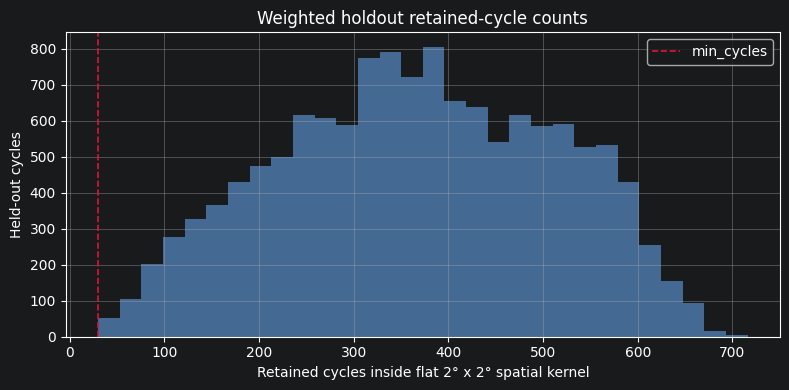

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
cycle_metrics["retained_cycle_count"].hist(ax=ax, bins=30, color="#4c78a8", alpha=0.85)
ax.axvline(config.min_cycles, color="crimson", linestyle="--", linewidth=1.2, label="min_cycles")
ax.set_title("Weighted holdout retained-cycle counts")
ax.set_xlabel("Retained cycles inside flat 2° x 2° spatial kernel")
ax.set_ylabel("Held-out cycles")
ax.legend()
plt.tight_layout()
plt.show()



## 6. Aggregate weighted-model performance by depth

These curves use the same format as the Jana benchmark notebook so the depthwise error structure can be compared visually and numerically.




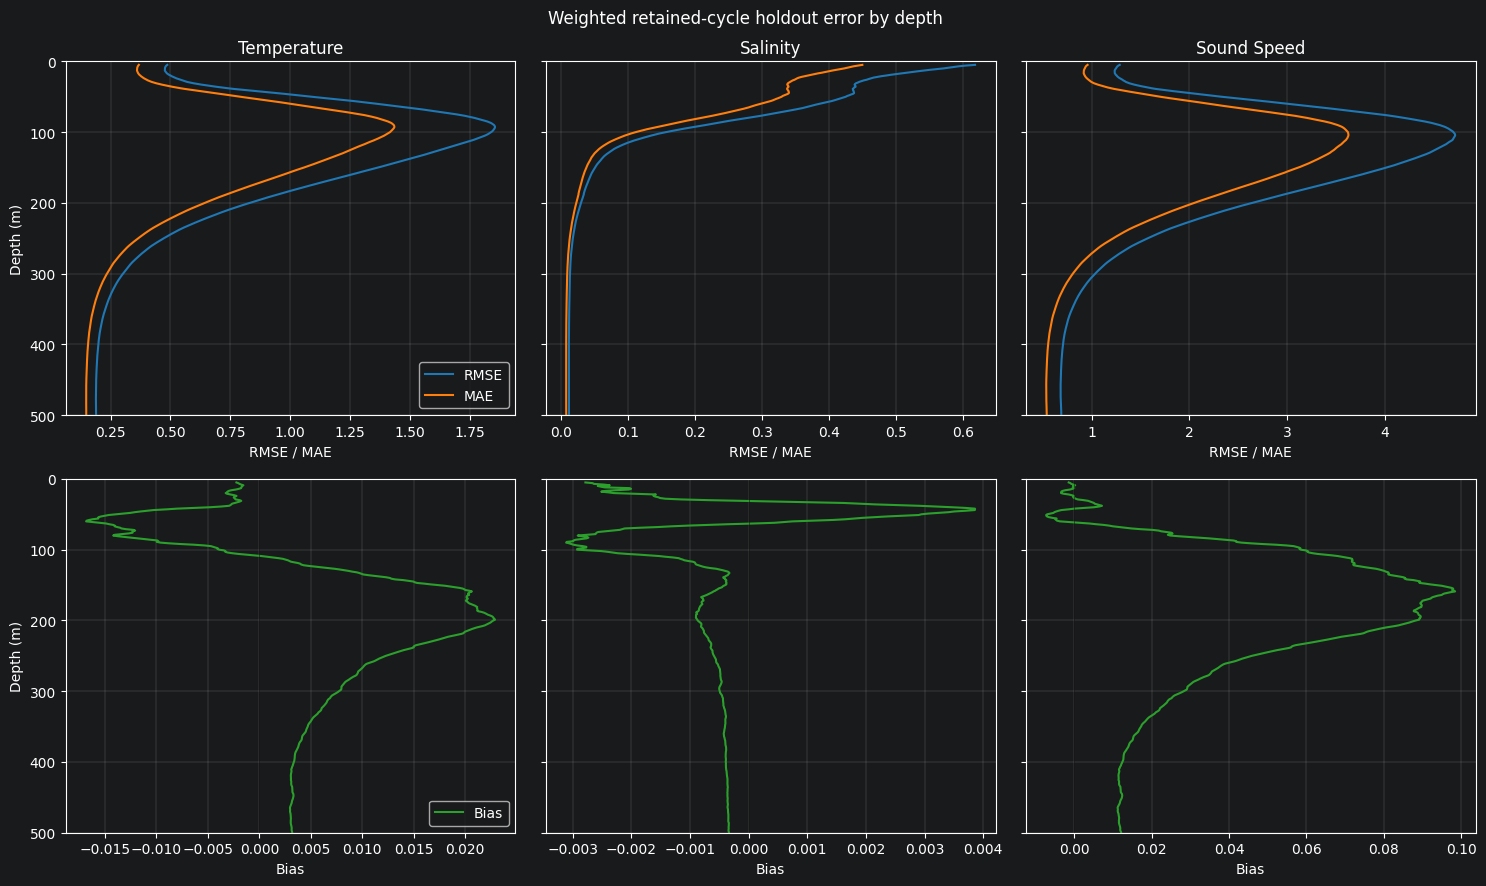

In [14]:
measure_order = ["temperature", "salinity", "sound_speed"]
measure_labels = {
    "temperature": "Temperature",
    "salinity": "Salinity",
    "sound_speed": "Sound Speed",
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharey=True)
for col, measure in enumerate(measure_order):
    measure_depth = depth_metrics[depth_metrics["measure"] == measure]
    metric_ax = axes[0, col]
    bias_ax = axes[1, col]

    metric_ax.plot(measure_depth["rmse"], measure_depth["depth"], label="RMSE", color="#1f77b4")
    metric_ax.plot(measure_depth["mae"], measure_depth["depth"], label="MAE", color="#ff7f0e")
    metric_ax.set_title(measure_labels[measure])
    metric_ax.set_xlabel("RMSE / MAE")
    metric_ax.set_ylim(500, 0)
    metric_ax.grid(True, linewidth=0.3, alpha=0.5)

    bias_ax.plot(measure_depth["bias"], measure_depth["depth"], label="Bias", color="#2ca02c")
    bias_ax.axvline(0, color="black", linewidth=0.6, alpha=0.5)
    bias_ax.set_xlabel("Bias")
    bias_ax.set_ylim(500, 0)
    bias_ax.grid(True, linewidth=0.3, alpha=0.5)

axes[0, 0].set_ylabel("Depth (m)")
axes[1, 0].set_ylabel("Depth (m)")
axes[0, 0].legend(loc="lower right")
axes[1, 0].legend(loc="lower right")
plt.suptitle("Weighted retained-cycle holdout error by depth")
plt.tight_layout()
plt.show()



In [15]:
cycle_metrics[[
    "temperature_rmse", "salinity_rmse", "sound_speed_rmse",
    "temperature_mae", "salinity_mae", "sound_speed_mae",
]].describe().T



,count,mean,std,min,25%,50%,75%,max
temperature_rmse,13283.0,0.761492,0.440742,0.103110,0.442545,0.643967,0.974711,3.627710
salinity_rmse,13283.0,0.160904,0.080670,0.018998,0.102261,0.144282,0.203058,0.879758
sound_speed_rmse,13283.0,2.071875,1.193354,0.255960,1.206934,1.763754,2.642060,9.918984
temperature_mae,13283.0,0.523888,0.304812,0.069372,0.305867,0.445564,0.663239,2.615969
salinity_mae,13283.0,0.071895,0.033917,0.010261,0.047613,0.064775,0.088917,0.358438
sound_speed_mae,13283.0,1.496465,0.870334,0.173699,0.868951,1.273429,1.897568,7.520581


## 7. Spatial coverage of evaluated and skipped cycles

This map uses the same visual logic as the Jana benchmark notebook. Differences in the skip pattern should come from the weighted model's support requirements rather than from a changed validation protocol.




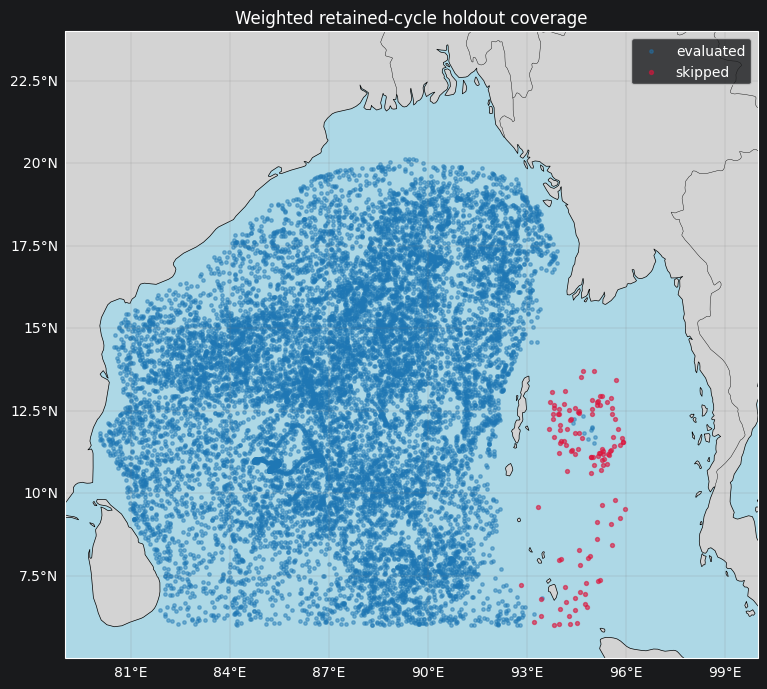

In [16]:
coverage_map = active_cycles_metadata.join(diagnostics[["status", "retained_cycle_count"]], how="left")

projection = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(8, 7), subplot_kw={"projection": projection})
ax.set_facecolor("lightblue")
ax.add_feature(cfeature.LAND, facecolor="lightgrey")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)
ax.set_extent([79, 100, 5, 24], crs=projection)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="grey", alpha=0.5)
gl.top_labels = False
gl.right_labels = False

ok_mask = coverage_map["status"] == "ok"
ax.scatter(
    coverage_map.loc[ok_mask, "longitude"],
    coverage_map.loc[ok_mask, "latitude"],
    s=6,
    c="#1f77b4",
    alpha=0.45,
    label="evaluated",
    transform=projection,
)
ax.scatter(
    coverage_map.loc[~ok_mask, "longitude"],
    coverage_map.loc[~ok_mask, "latitude"],
    s=8,
    c="crimson",
    alpha=0.6,
    label="skipped",
    transform=projection,
)
ax.legend(loc="upper right")
ax.set_title("Weighted retained-cycle holdout coverage")
plt.tight_layout()
plt.show()



## 8. Example held-out profiles

These examples keep the same role as the Jana benchmark notebook, but they also expose the weighted retained-cycle cloud behind each prediction.




In [17]:
def plot_sample_profile(cycle_id: str) -> None:
    sample = sample_profiles[cycle_id]
    predicts = sample["predicts"]
    actuals = sample["actuals"]
    retained_cycle_count = sample["diagnostics"]["retained_cycle_count"]
    weights = sample["weights"]
    actual_color = "#444444"

    fig, axes = plt.subplots(1, 3, figsize=(12, 6), sharey=True)
    for ax, measure, color in zip(
        axes,
        ["temperature", "salinity", "sound_speed"],
        ["#1f77b4", "#2ca02c", "#d62728"],
    ):
        if measure in {"temperature", "salinity"}:
            profile_grid = temp_active_profiles if measure == "temperature" else sal_active_profiles
            for retained_cycle_id, weight in weights.items():
                ax.plot(
                    profile_grid[retained_cycle_id],
                    profile_grid.index,
                    color=color,
                    alpha=float(0.05 + 0.25 * weight),
                    linewidth=0.5,
                )
        else:
            for retained_cycle_id, weight in weights.items():
                ax.plot(
                    sound_speed_profiles[retained_cycle_id],
                    sound_speed_profiles.index,
                    color=color,
                    alpha=float(0.05 + 0.25 * weight),
                    linewidth=0.5,
                )

        ax.plot(actuals[measure], actuals.index, label="actual", color=actual_color, linewidth=1.8)
        ax.plot(predicts[measure], predicts.index, label="predicted", color=color, linewidth=1.5)
        ax.set_title(measure_labels[measure])
        ax.set_xlabel(measure)
        ax.set_ylim(500, 0)
        ax.grid(True, linewidth=0.3, alpha=0.5)

    axes[0].set_ylabel("Depth (m)")
    axes[0].legend(loc="lower right")
    plt.suptitle(
        f"{cycle_id} | Weighted holdout prediction | retained cycles={retained_cycle_count}"
    )
    plt.tight_layout()
    plt.show()



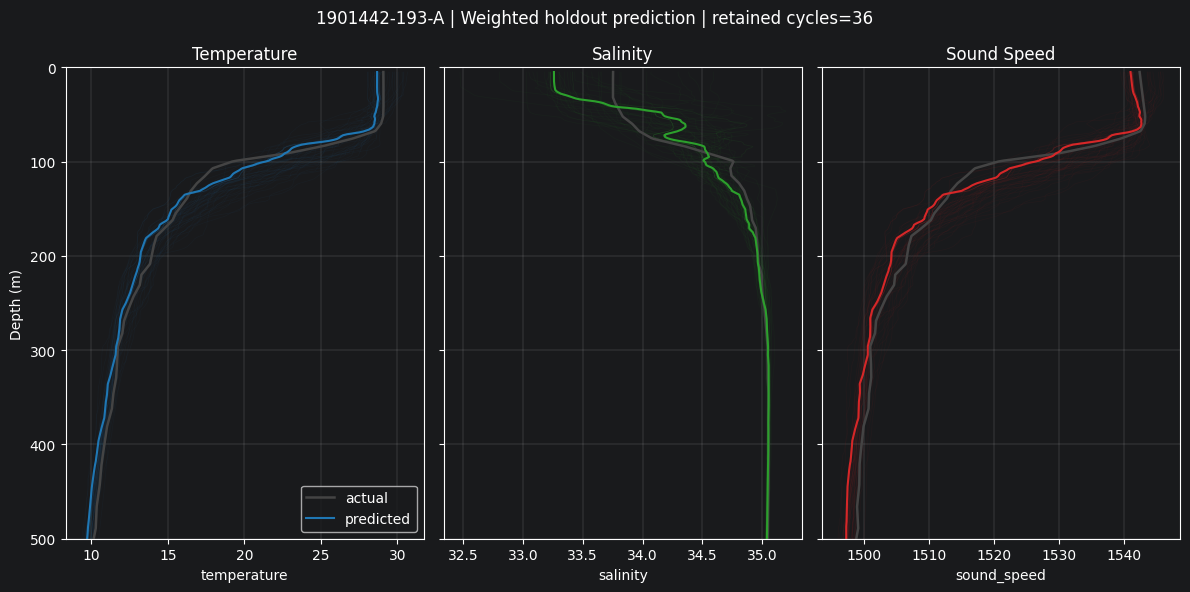

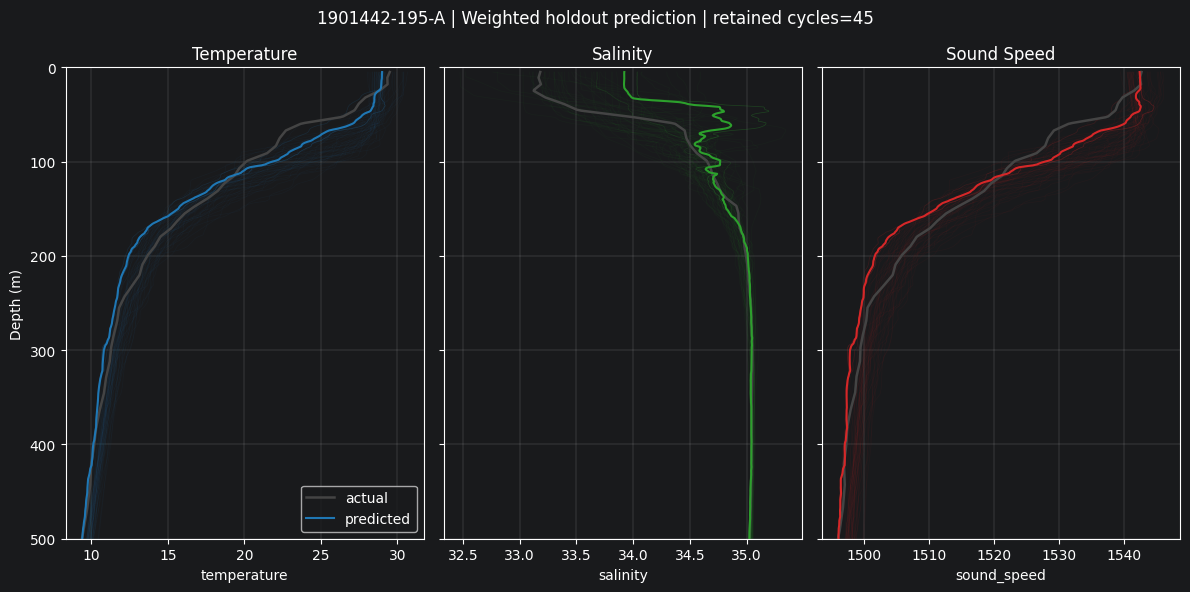

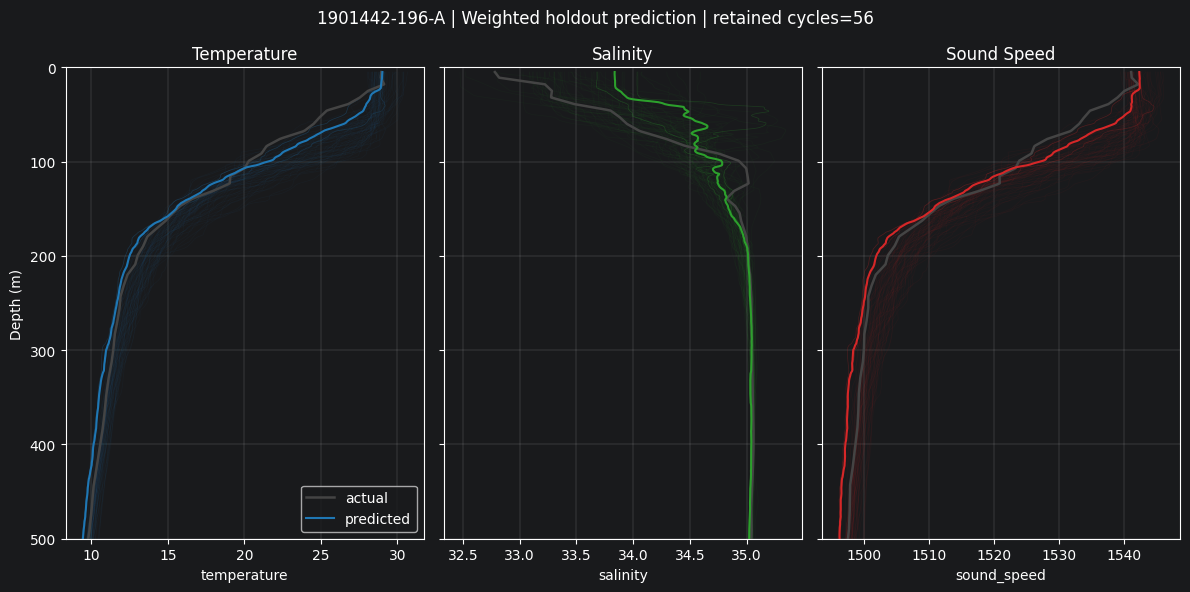

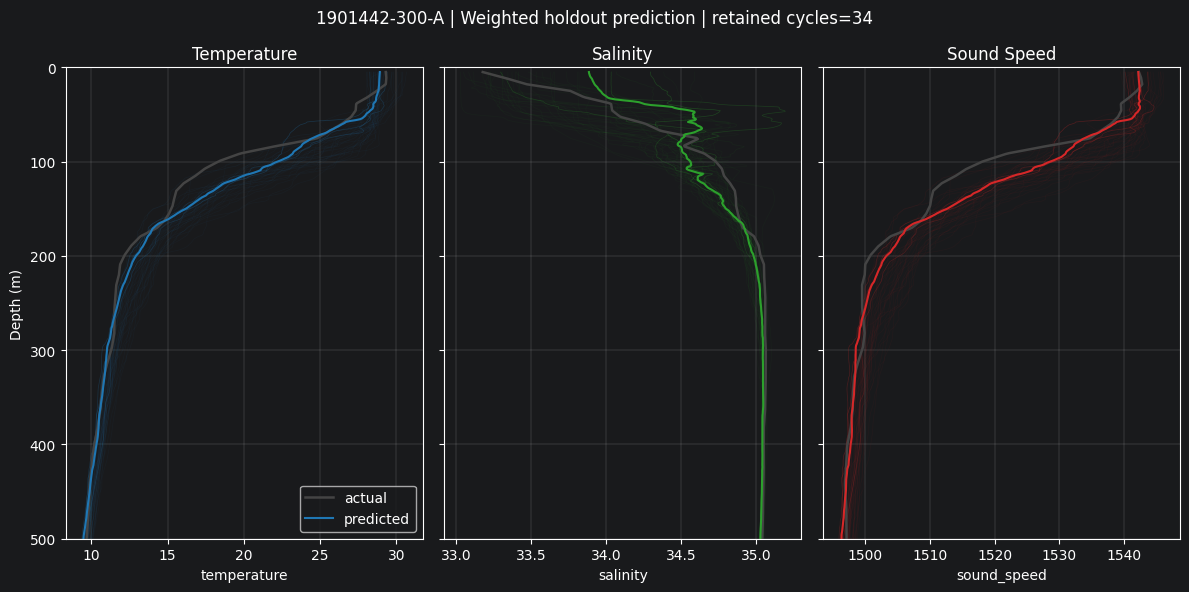

In [18]:
for cycle_id in sample_profiles:
    plot_sample_profile(cycle_id)



## 9. Interpretation and next step

This notebook now answers the same held-out benchmark question as `2-jana-holdout-validation.ipynb`, but with a weighted retained-cycle predictor instead of a flat local mean.

The immediate comparison is empirical:
- compare this notebook's depthwise RMSE / MAE / bias against the flat Jana benchmark from notebook `2`
- inspect whether the weighted predictor improves specific depth ranges or only certain coverage regimes
- decide whether the extra weighting complexity is justified when the archive remains strictly pruned

The next notebook in the sequence, `4-uncertainty-extension-all-cycles.ipynb`, changes a different lever. It keeps the weighted local-window idea from this notebook, but relaxes the archive-retention rules so partially sampled cycles can contribute where they have real depth support.

That makes notebook `4` a complementary test rather than a replacement:
- notebook `3` asks whether weighting helps under the strict Jana-style retained archive
- notebook `4` asks whether the same weighted idea benefits from keeping more partial local support
